# 04 — Robustness and Out-of-Assumption Stress Tests

Gaussian increments, AR(1) dependence, model misspecification, and overshoot. These are robustness diagnostics outside parts of the current finite-confidence theory.

**Execution modes:** `SMOKE_TEST=1` performs a small offline code-path check; default settings run a moderate benchmark; `FULL_RUN=1` enables publication-scale Monte Carlo. Smoke outputs are verification-only and must not be reported as experimental results.

In [1]:
from pathlib import Path
import os, sys, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == 'notebooks' else HERE
if not (ROOT/'src'/'gated_benchmarks.py').exists():
    for cand in [HERE, *HERE.parents]:
        if (cand/'src'/'gated_benchmarks.py').exists():
            ROOT = cand; break
sys.path.insert(0, str(ROOT/'src'))
( ROOT/'results').mkdir(exist_ok=True)
( ROOT/'figures').mkdir(exist_ok=True)
FULL_RUN = os.getenv('FULL_RUN','0') == '1'
SMOKE_TEST = os.getenv('SMOKE_TEST','0') == '1'
print('ROOT =', ROOT)
print('FULL_RUN =', FULL_RUN, 'SMOKE_TEST =', SMOKE_TEST)


ROOT = /mnt/data/gated_certification_benchmarks
FULL_RUN = False SMOKE_TEST = True


In [2]:
from gated_benchmarks import *
means=[(0.0,0.35),(0.0,1.2)]  # (mu0,mu1) per level; evidence under H0 is positive with LLR log f0/f1
sigma=1.0; delta=.01; alpha=.05
print('Gaussian KLs:',[gaussian_kl(a,b,sigma) for a,b in means])


Gaussian KLs: [0.06124999999999999, 0.72]


## 1. Gaussian iid stress test

In [3]:
n=200 if SMOKE_TEST else (2000 if not FULL_RUN else 10000)
rows=[]
for h in [0,1]:
    df=simulate_gaussian_binary(means,None,sigma,[alpha],delta,h,n_trials=n,seed=10+h,corr=0)
    s=summarize_binary_runs(df); rows.append({'setting':'iid Gaussian','true_h':h,**s})
g=pd.DataFrame(rows); display(g)


,setting,true_h,n_trials,mean_tau,mean_tau_ci_lo,mean_tau_ci_hi,median_tau,q95_tau,error_rate,error_ci_lo,error_ci_hi,false_unlock_rate,false_unlock_ci_lo,false_unlock_ci_hi,failed_unlock_rate,mean_relocks,mean_N1,mean_N2
0,iid Gaussian,0,200,49.795,45.082511,54.507489,40.0,120.10,0.0,1.734723e-18,0.018845,0.000,1.734723e-18,0.018845,0.0,NaN,46.71,3.085
1,iid Gaussian,1,200,73.215,68.029593,78.400407,67.0,141.15,0.0,1.734723e-18,0.018845,0.025,1.072472e-02,0.057178,0.0,NaN,72.94,0.275


## 2. Dependence stress test: AR(1) correlation

In [4]:
rows=[]
for corr in [0,.1,.3,.5,.8]:
    for h in [0,1]:
        df=simulate_gaussian_binary(means,None,sigma,[alpha],delta,h,n_trials=n,seed=100+int(100*corr)+h,corr=corr)
        s=summarize_binary_runs(df); rows.append({'corr':corr,'true_h':h,**s})
corr_df=pd.DataFrame(rows); corr_df.to_csv(ROOT/'results'/'correlation_stress.csv',index=False); display(corr_df[['corr','true_h','mean_tau','error_rate','false_unlock_rate']])


,corr,true_h,mean_tau,error_rate,false_unlock_rate
0,0.0,0,61.395,0.015,0.000
1,0.0,1,78.415,0.005,0.045
2,0.1,0,49.140,0.010,0.000
3,0.1,1,71.310,0.015,0.095
4,0.3,0,48.505,0.050,0.000
5,0.3,1,64.755,0.020,0.150
6,0.5,0,44.815,0.120,0.000
7,0.5,1,55.340,0.110,0.200
8,0.8,0,30.095,0.245,0.000
9,0.8,1,34.295,0.275,0.385


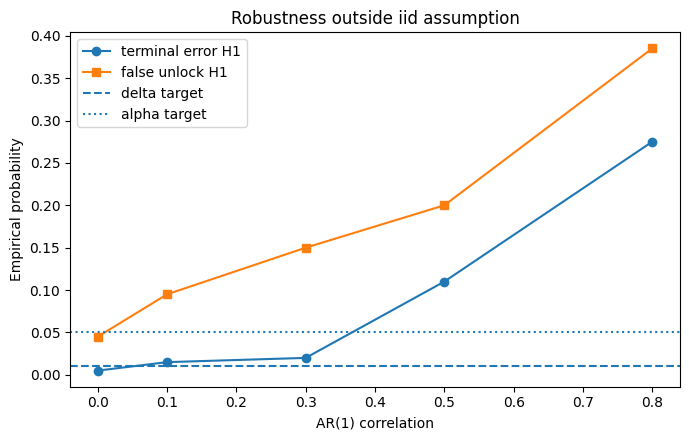

In [5]:
fig,ax=plt.subplots(figsize=(7,4.5)); q=corr_df[corr_df.true_h==1]; ax.plot(q['corr'],q.error_rate,marker='o',label='terminal error H1'); ax.plot(q['corr'],q.false_unlock_rate,marker='s',label='false unlock H1'); ax.axhline(delta,linestyle='--',label='delta target'); ax.axhline(alpha,linestyle=':',label='alpha target'); ax.set_xlabel('AR(1) correlation'); ax.set_ylabel('Empirical probability'); ax.legend(); ax.set_title('Robustness outside iid assumption'); fig.tight_layout(); fig.savefig(ROOT/'figures'/'correlation_stress.png',dpi=180); plt.show()


## 3. Model misspecification

In [6]:
rows=[]
for eps in [0,.01,.05,.10]:
    # Algorithm uses a shifted H1 model while data come from the original means.
    model=[(means[0][0],means[0][1]+eps),(means[1][0],means[1][1]+eps)]
    for h in [0,1]:
        df=simulate_gaussian_binary(means,model,sigma,[alpha],delta,h,n_trials=n,seed=300+int(eps*1000)+h,corr=0)
        s=summarize_binary_runs(df); rows.append({'misspec':eps,'true_h':h,**s})
mis=pd.DataFrame(rows); mis.to_csv(ROOT/'results'/'misspecification_stress.csv',index=False); display(mis[['misspec','true_h','mean_tau','error_rate','false_unlock_rate']])


,misspec,true_h,mean_tau,error_rate,false_unlock_rate
0,0.00,0,55.050,0.025,0.000
1,0.00,1,71.045,0.010,0.035
2,0.01,0,50.750,0.000,0.000
3,0.01,1,78.180,0.000,0.015
4,0.05,0,43.490,0.000,0.000
5,0.05,1,72.105,0.010,0.090
6,0.10,0,35.145,0.010,0.000
7,0.10,1,60.675,0.025,0.115


## 4. Overshoot distributions

count    200.000000
mean       0.201787
std        0.175291
min        0.001766
50%        0.160069
90%        0.433445
95%        0.526830
99%        0.888021
max        0.909396
Name: overshoot1, dtype: float64


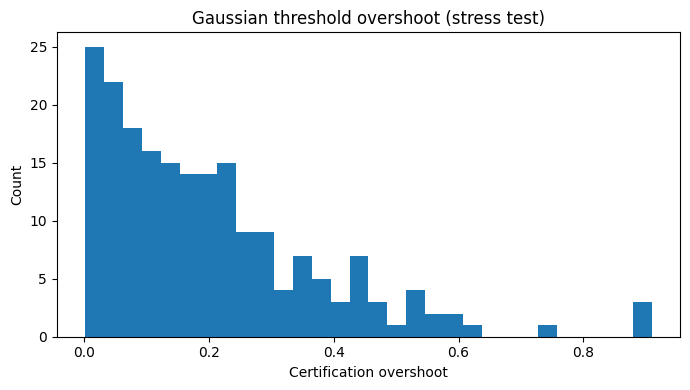

In [7]:
df=simulate_gaussian_binary(means,None,sigma,[alpha],delta,0,n_trials=n,seed=444,corr=0); ov=df.overshoot1.dropna(); print(ov.describe(percentiles=[.5,.9,.95,.99]));
fig,ax=plt.subplots(figsize=(7,4)); ax.hist(ov,bins=30); ax.set_xlabel('Certification overshoot'); ax.set_ylabel('Count'); ax.set_title('Gaussian threshold overshoot (stress test)'); fig.tight_layout(); fig.savefig(ROOT/'figures'/'gaussian_overshoot.png',dpi=180); plt.show()


### Reporting rule
These experiments should appear under **Robustness beyond the formal assumptions**. Correlation and model misspecification intentionally violate the theorem model; Gaussian increments also violate the bounded-increment condition used for the explicit nonasymptotic overshoot bound. Report failures as informative boundary cases rather than hiding them.